In [78]:
import pandas as pd

# Load CSV
df = pd.read_csv("./data/transactions.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time
df = df.sort_values("timestamp")

# Opening balance
opening_balance = 50000

# Running balance
df["running_balance"] = opening_balance + df["amount"].cumsum()

# Target date
target_date = pd.to_datetime("2026-04-28").date()

# Filter up to that date
filtered = df[df["timestamp"].dt.date <= target_date]

if not filtered.empty:
    balance = filtered.iloc[-1]["running_balance"]
    print(f"Balance on 27 March 2026: ₹{balance:,.2f}")
else:
    print("No transactions found before this date.")

Balance on 27 March 2026: ₹591,150.08


In [79]:
# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Filter only income
income_df = df[df["amount"] > 0]

# Total number of income transactions
income_count = len(income_df)

print(f"Total income transactions: {income_count}\n")

# Show when income came
print("Income dates and amounts:")
print(income_df[["timestamp", "amount"]].sort_values("timestamp"))

Total income transactions: 76

Income dates and amounts:
               timestamp    amount
9    2025-01-03 20:43:52     92.12
18   2025-01-06 19:13:24    512.93
42   2025-01-14 19:40:00    433.93
59   2025-01-21 13:11:33   5788.02
75   2025-01-28 07:13:14  59271.61
...                  ...       ...
1352 2026-03-28 10:19:58  52364.18
1378 2026-04-05 13:25:24  10438.22
1404 2026-04-13 14:20:06   9909.15
1425 2026-04-21 18:18:41    122.03
1447 2026-04-28 09:53:33  68141.77

[76 rows x 2 columns]


In [80]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Only income transactions
income_df = df[df["amount"] > 0].copy()

# Create month column
income_df["month"] = income_df["timestamp"].dt.to_period("M")

# Count income transactions per month
monthly_income_check = (
    income_df.groupby("month")
    .size()
    .reset_index(name="income_count")
)

# Mark whether income exists
monthly_income_check["salary_present"] = monthly_income_check["income_count"] > 0

print(monthly_income_check)

      month  income_count  salary_present
0   2025-01             5            True
1   2025-02             5            True
2   2025-03             4            True
3   2025-04             4            True
4   2025-05             3            True
5   2025-06             3            True
6   2025-07             3            True
7   2025-08             5            True
8   2025-09             7            True
9   2025-10             6            True
10  2025-11             6            True
11  2025-12             4            True
12  2026-01             5            True
13  2026-02             5            True
14  2026-03             7            True
15  2026-04             4            True


In [81]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

opening_balance = 50000
df["running_balance"] = opening_balance + df["amount"].cumsum()

# Set timestamp as index
df = df.set_index("timestamp")

In [82]:
today = df.last("1D")
last_7d = df.last("7D")
last_30d = df.last("30D")
last_3m = df.last("90D")
last_1y = df.last("365D")
all_data = df

C:\Users\USER\AppData\Local\Temp\ipykernel_210188\4180967107.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  today = df.last("1D")
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\4180967107.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_7d = df.last("7D")
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\4180967107.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_30d = df.last("30D")
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\4180967107.py:4: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_3m = df.last("90D")
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\4180967107.py:5: FutureWarning: last is deprecated and will be re

In [83]:
df.head()

,id,description,category,amount,type,running_balance
timestamp,,,,,,
2025-01-01 09:20:25,3,Medical Consultation,Other,-395.18,expense,49604.82
2025-01-01 09:46:39,1,Rent Payment,Rent,-13039.51,expense,36565.31
2025-01-01 16:21:05,2,Street Food,Food,-63.15,expense,36502.16
2025-01-01 20:13:23,4,Restaurant Dinner,Food,-439.55,expense,36062.61
2025-01-02 10:42:11,7,Petrol Station,Travel,-1145.04,expense,34917.57


In [84]:
filters = {
    "Today": df.last("1D"),
    "7D": df.last("7D"),
    "30D": df.last("30D"),
    "3M": df.last("90D"),
    "1Y": df.last("365D"),
    "All": df
}

for key, data in filters.items():
    print(f"\n--- {key} ---")
    print(data[["running_balance"]].tail())


--- Today ---
                     running_balance
timestamp                           
2026-04-30 13:15:31        588906.50
2026-04-30 18:02:35        588356.84
2026-04-30 22:00:07        588190.23

--- 7D ---
                     running_balance
timestamp                           
2026-04-29 12:17:27        590857.82
2026-04-29 13:30:33        589175.66
2026-04-30 13:15:31        588906.50
2026-04-30 18:02:35        588356.84
2026-04-30 22:00:07        588190.23

--- 30D ---
                     running_balance
timestamp                           
2026-04-29 12:17:27        590857.82
2026-04-29 13:30:33        589175.66
2026-04-30 13:15:31        588906.50
2026-04-30 18:02:35        588356.84
2026-04-30 22:00:07        588190.23

--- 3M ---
                     running_balance
timestamp                           
2026-04-29 12:17:27        590857.82
2026-04-29 13:30:33        589175.66
2026-04-30 13:15:31        588906.50
2026-04-30 18:02:35        588356.84
2026-04-30 22:00:07    

C:\Users\USER\AppData\Local\Temp\ipykernel_210188\405345238.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "Today": df.last("1D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\405345238.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "7D": df.last("7D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\405345238.py:4: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "30D": df.last("30D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\405345238.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "3M": df.last("90D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\405345238.py:6: FutureWarning: last is deprecated and will be removed in a f

C:\Users\USER\AppData\Local\Temp\ipykernel_210188\58110418.py:18: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "Last 7 Days": daily_balance.last("7D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\58110418.py:19: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "Last 30 Days": daily_balance.last("30D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\58110418.py:20: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "Last 3 Months": daily_balance.last("90D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_210188\58110418.py:21: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  "Last 6 Months": daily_balance.last("180D"),
C:\Users\USER\AppData\Local\Temp\ipykernel_

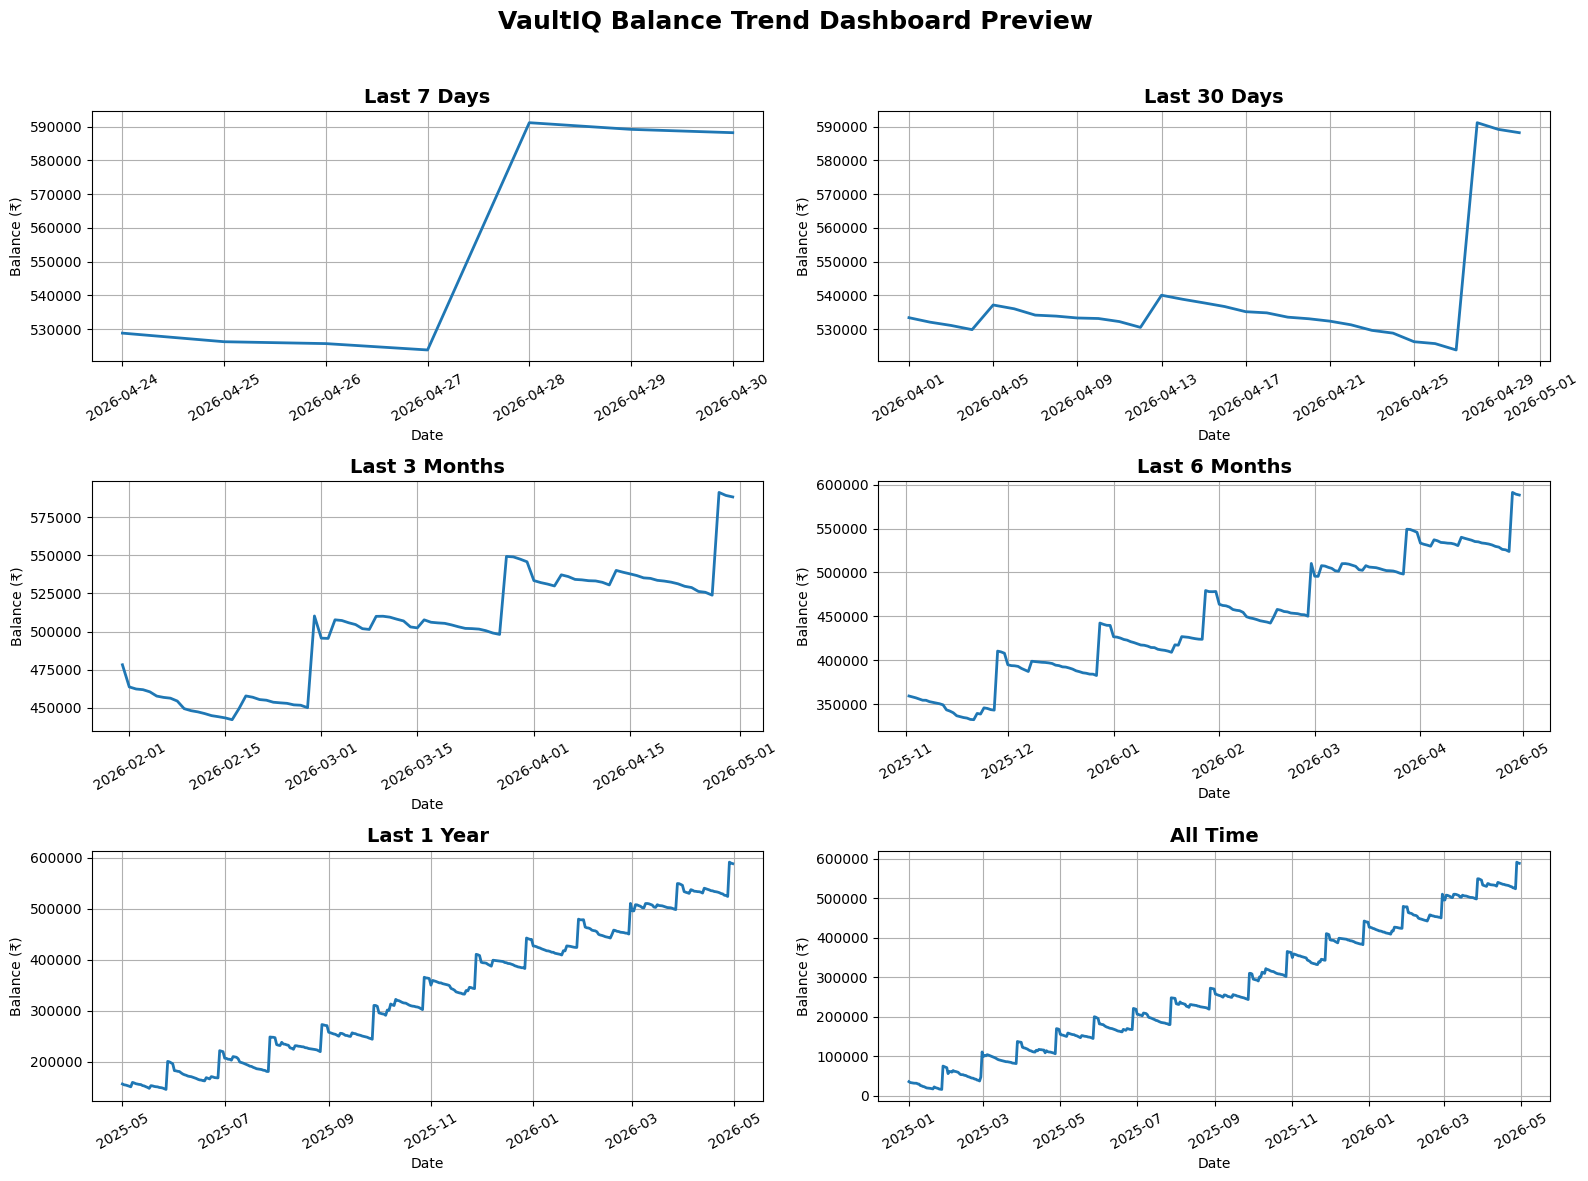

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Smooth daily closing balance
daily_balance = (
    df["running_balance"]
    .resample("D")
    .last()
    .ffill()
)

# Create filtered datasets
graphs = {
    "Last 7 Days": daily_balance.last("7D"),
    "Last 30 Days": daily_balance.last("30D"),
    "Last 3 Months": daily_balance.last("90D"),
    "Last 6 Months": daily_balance.last("180D"),
    "Last 1 Year": daily_balance.last("365D"),
    "All Time": daily_balance
}

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (title, data) in zip(axes, graphs.items()):
    ax.plot(data.index, data.values, linewidth=2)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Balance (₹)")
    ax.grid(True)
    ax.tick_params(axis="x", rotation=30)

# Main heading
fig.suptitle("VaultIQ Balance Trend Dashboard Preview", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()